# Mecanum Trajectory Physics Diagnostic — v2

A standalone, model-free check for how well each Julia-emitted trajectory
satisfies the Mecanum platform's equations of motion. We re-derive the
physics residuals used by `Mecanum_PINN_Trainer_11`, but evaluate them on
the **recorded** state, force, and control time series — no neural network
involved — and use the resulting per-trajectory numbers to classify
trajectories by physics-consistency.

## What changed in v2

- Added **Simpson's rule** as a third discrete residual (centered 3-point
  Newton-Cotes, $\mathcal{O}(\Delta t^4)$). With endpoint-only data this is
  the highest-order quadrature you can construct without midpoint forces.
- Added **`sampling_dt`** to the config so the diagnostic can subsample the
  saved 0.001-s Julia grid down to any coarser step. Lets you do a
  Richardson convergence study on real trajectories without re-running the
  simulator.
- Updated the Richardson plot to show Euler / Trap / Simpson on the same
  log-log axes with slope-1, slope-2, slope-4 reference lines.

## Five metrics per trajectory

| Metric | Formulation | Order | Role |
|---|---|---|---|
| `L_euler`    | Forward-Euler with implicit wheel damping (matches the PINN trainer's discrete inverse residual) | $\mathcal{O}(\Delta t)$ | Reproduces the trainer's metric for direct comparison |
| `L_trap`     | Symmetric trapezoidal (Crank–Nicolson), endpoint-only | $\mathcal{O}(\Delta t^{2})$ | Baseline upgrade — same data, $\sim$50$\times$ tighter floor |
| `L_simpson`  | Centered 3-point Newton-Cotes (Simpson) using $(n-1, n, n+1)$ | $\mathcal{O}(\Delta t^{4})$ | Highest-order rule available without midpoint forces |
| `L_cont_FD`  | Continuous-time residual using centered finite-difference $\partial S/\partial t$ | (depends on derivative noise) | Mirrors the trainer's continuous forward residual |
| `L_cont_RHS` | Continuous-time residual using the analytical ODE RHS at recorded $(s, F, u)$ | machine-precision in $\partial S/\partial t$ | Should be $\approx 0$ — flags data-loading or scaling bugs |

## How to read the metric ladder

Under dt-refinement on a smooth, well-resolved trajectory the residuals
should converge in the textbook way:

$$
\frac{L_{\text{simpson}}(\Delta t/2)}{L_{\text{simpson}}(\Delta t)} \to \tfrac{1}{16},
\quad
\frac{L_{\text{trap}}(\Delta t/2)}{L_{\text{trap}}(\Delta t)} \to \tfrac{1}{4},
\quad
\frac{L_{\text{euler}}(\Delta t/2)}{L_{\text{euler}}(\Delta t)} \to \tfrac{1}{2}
$$

If Simpson **stops** dropping at slope 4 while Euler and Trap still do, the
residual has hit a non-discretization floor — most likely the **interpolation
error in $F(\tau)$** between saved gridpoints. That floor is the irreducible
limit of any endpoint-only quadrature; you can't beat it without sub-step
force samples.

This is precisely why we want Simpson in the diagnostic before promoting
any new scheme to the trainer: if it doesn't give a slope-4 line, there's
no point upgrading the trainer's discrete residual past trapezoidal.

## Imports

Numpy + scipy + pandas + matplotlib + pyarrow. No torch.

In [1]:
import math
import re
from pathlib import Path
import joblib
from dataclasses import dataclass, field
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.signal import savgol_filter, decimate

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.notebook import tqdm

import pyarrow as pa
import pyarrow.feather as feather

np.random.seed(42)





## Config

Two new fields relative to v1:

- `saved_dt` — the time step at which Julia wrote samples to the Arrow files.
  With `saveat = T/(2*T_period*1000) = 0.001` this is `0.001`. Used only
  to validate that subsampling factors are integer ratios.

- `sampling_dt` — the effective time step the diagnostic operates on. The
  loader takes every $k = \mathrm{round}(\texttt{sampling\_dt}/\texttt{saved\_dt})$-th
  sample from each trajectory. Setting `sampling_dt = saved_dt` disables
  subsampling. Default `0.005` matches your stated training-window plan
  (150 samples over 750 ms).

The classification thresholds and FD edge-drop are unchanged from v1.

In [2]:
config = {
    # ---- Data ----
    "data_dir":       r"G:\My Drive\SimulationDataSlipSpin_Julia_2",
    "mu_values":      None,
    "motion_cases":   None,
    "friction_case":  1,

    # ---- Sampling (NEW in v2) ----
    "saved_dt":       0.001,    # Julia driver's saveat step
    "sampling_dt":    0.005,    # diagnostic-grid step (>= saved_dt, integer multiple)
    "max_window_sec": None,     # if not None, truncate each trajectory to this many seconds

    # ---- Residual scaling ----
    "force_max":      100.0,
    "control_max":    10.0,
    "w_max":          30.0,

    # ---- Numerical-derivative options ----
    "fd_edge_drop":   2,
    "spline_bc":      "not-a-knot",

    # ---- Classification ----
    "tier_quantiles":      (0.50, 0.90),
    "fd_rhs_gap_quantile": 0.90,

    # ---- Plotting ----
    "figsize_dist":   (15, 4),
    "figsize_traj":   (14, 8),
    "max_traj_plots": 6,
}

_P1_BY_CASE = {1: 0.11, 2: 0.011}
config["p1_wheel"] = _P1_BY_CASE[config["friction_case"]]

# Validate sampling_dt is a clean integer multiple of saved_dt
_sub_factor = config["sampling_dt"] / config["saved_dt"]
if abs(_sub_factor - round(_sub_factor)) > 1e-9:
    raise ValueError(f"sampling_dt ({config['sampling_dt']}) must be an integer "
                     f"multiple of saved_dt ({config['saved_dt']}); got ratio "
                     f"{_sub_factor}")
config["_subsample_factor"] = int(round(_sub_factor))

print(f"[config] friction_case={config['friction_case']}  =>  p1_wheel={config['p1_wheel']}")
print(f"[config] saved_dt={config['saved_dt']} s, sampling_dt={config['sampling_dt']} s, "
      f"subsample factor={config['_subsample_factor']}")

[config] friction_case=1  =>  p1_wheel=0.11
[config] saved_dt=0.001 s, sampling_dt=0.005 s, subsample factor=5


## RobotParams — physical constants

Same numbers as `Mecanum_PINN_Trainer_11`'s `RobotParams` and the Julia
simulator's `PlatformParams`. Numpy-only.

In [3]:
@dataclass
class RobotParams:
    h:  float = 0.235
    l:  float = 0.150
    R1: float = 0.05

    m:        float = 30.0
    m_wheel:  float = 1.4
    Jw_1:     float = 5.87e-3
    Is:       float = 4.42

    aX: float = 1.6e-2
    aY: float = -2.6e-2

    p1_wheel: Optional[float] = None

    ms:           Optional[float]      = None
    N_total:      Optional[float]      = None
    N_per_roller: Optional[np.ndarray] = None
    wc_x:         Optional[np.ndarray] = None
    wc_y:         Optional[np.ndarray] = None
    delta:        Optional[np.ndarray] = None
    M:            Optional[np.ndarray] = None
    M_inv:        Optional[np.ndarray] = None

    Jw: Optional[float] = None
    R:  Optional[float] = None
    p1: Optional[float] = None

    def finalize(self, p1_wheels: float):
        self.p1_wheel = p1_wheels
        self.p1       = p1_wheels
        self.Jw       = self.Jw_1
        self.R        = self.R1

        self.ms      = self.m + 4.0 * self.m_wheel
        self.N_total = self.ms * 9.81

        N1 = self.N_total / 4 * (1 + self.aX/self.h + self.aY/self.l) + self.m_wheel * 9.81
        N2 = self.N_total / 4 * (1 + self.aX/self.h - self.aY/self.l) + self.m_wheel * 9.81
        N3 = self.N_total / 4 * (1 - self.aX/self.h + self.aY/self.l) + self.m_wheel * 9.81
        N4 = self.N_total / 4 * (1 - self.aX/self.h - self.aY/self.l) + self.m_wheel * 9.81
        self.N_per_roller = np.array([N1, N2, N3, N4], dtype=np.float64)

        self.wc_x  = np.array([+self.h, +self.h, -self.h, -self.h], dtype=np.float64)
        self.wc_y  = np.array([+self.l, -self.l, +self.l, -self.l], dtype=np.float64)
        self.delta = np.array([-np.pi/4, np.pi/4, np.pi/4, -np.pi/4], dtype=np.float64)

        self.M = np.array([
            [self.ms, 0.0,             -self.m * self.aY],
            [0.0,     self.ms,          self.m * self.aX],
            [-self.m * self.aY,  self.m * self.aX, self.Is],
        ], dtype=np.float64)
        self.M_inv = np.linalg.inv(self.M)
        return self


rp = RobotParams().finalize(p1_wheels=config["p1_wheel"])
print(f"[robot] m={rp.m} kg, ms={rp.ms} kg, Is={rp.Is} kg·m²")
print(f"[robot] M =\n{rp.M}")

[robot] m=30.0 kg, ms=35.6 kg, Is=4.42 kg·m²
[robot] M =
[[35.6   0.    0.78]
 [ 0.   35.6   0.48]
 [ 0.78  0.48  4.42]]


## Data loading — Arrow files with subsampling

The loader behaves like v1's, with two new optional steps applied per
trajectory after reading:

1. **Subsample** by `_subsample_factor` so the working grid has
   `dt = sampling_dt`.
2. **Truncate** to the first `max_window_sec` seconds if set, so the
   diagnostic operates on a fixed-length window matching what the trainer
   sees.

Both transformations preserve the time-stamps as recorded — there's no
interpolation. We're just reading every $k$-th saved row.

In [4]:
_ARROW_STATE_COLS   = ["Vx", "Vy", "psi_dot",
                       "w1", "w2", "w3", "w4",
                       "theta1", "theta2", "theta3", "theta4"]
_ARROW_CONTROL_COLS = ["Msat_1", "Msat_2", "Msat_3", "Msat_4"]
_ARROW_FORCE_COLS   = ["Fx_1", "Fx_2", "Fx_3", "Fx_4",
                       "Fy_1", "Fy_2", "Fy_3", "Fy_4"]
_ARROW_TIME_COL     = "time"
_ARROW_TRAJ_KEYS    = ["beta", "amplitude", "T_period"]

_ALL_MOTION_CASES = ("straightline", "sineline", "smoothsquare",
                     "infinity", "circle")

_FILENAME_RE = re.compile(
    r"^test_mu_(?P<mu>[0-9.eE+\-]+)_"
    r"(?P<motion>[a-zA-Z]+)_"
    r"asmc_case(?P<fc>\d+)_"
    r"psi_var_beta(?P<beta>[0-9.eE+\-]+)_"
    r"amp(?P<amp>[0-9.eE+\-]+)_"
    r"chi_(?P<chi>[0-9.eE+\-]+)\.arrow$"
)


def _parse_arrow_filename(path: Path):
    m = _FILENAME_RE.match(path.name)
    if not m:
        return None, None, None
    try:
        mu = float(m.group("mu"))
    except ValueError:
        mu = None
    return mu, m.group("motion"), int(m.group("fc"))


def _mu_matches(mu_from_name, mu_values, atol=1e-9):
    if mu_values is None:
        return True
    if mu_from_name is None:
        return False
    return any(abs(mu_from_name - float(m)) <= atol for m in mu_values)




# Column indices into the (T, 11) `states` matrix corresponding to theta1..theta4.
# These accumulate monotonically and must be index-sliced, not low-pass filtered.
# Order matches _ARROW_STATE_COLS: ['Vx','Vy','psi_dot','w1','w2','w3','w4',
#                                    'theta1','theta2','theta3','theta4']
_STATE_NOFILTER_COLS = (7, 8, 9, 10)  # theta1..theta4


def _antialias_decimate(arr: np.ndarray, factor: int,
                        no_filter_cols=()) -> np.ndarray:
    """Downsample a (T,) or (T,K) array by `factor` with anti-aliasing.

    Columns whose indices are in `no_filter_cols` (only meaningful for 2-D
    arrays) are index-sliced instead of filtered — used for monotonic /
    accumulating channels like wheel angles.
    """
    if factor < 2:
        return arr.copy()
    if arr.ndim == 1:
        return decimate(arr, factor, n=8, ftype='iir',
                        axis=0, zero_phase=True)
    # 2-D: filter most columns, slice the rest, then reassemble in original order
    K = arr.shape[1]
    no_filt = set(no_filter_cols)
    filt_cols   = [c for c in range(K) if c not in no_filt]
    nofilt_cols = [c for c in range(K) if c     in no_filt]
    # New length is the same for both branches because decimate's output length
    # equals ceil(T / factor), matching `arr[::factor]`.
    out_len = arr[::factor].shape[0]
    out = np.empty((out_len, K), dtype=arr.dtype)
    if filt_cols:
        out[:, filt_cols] = decimate(arr[:, filt_cols], factor, n=8,
                                     ftype='iir', axis=0, zero_phase=True)
    if nofilt_cols:
        out[:, nofilt_cols] = arr[::factor, nofilt_cols]
    return out


def _apply_window(traj: Dict[str, Any], subsample_factor: int,
                  max_window_sec: Optional[float]) -> Dict[str, Any]:
    """Anti-alias-downsample then truncate one trajectory in-place.

    For subsample_factor >= 2:
      - states[:, theta_cols]  → index-sliced (monotonic, accumulating)
      - states[:, other_cols]  → low-pass filtered, then decimated
      - controls, forces       → low-pass filtered, then decimated
      - times                  → index-sliced (monotonic)

    The anti-alias step matters whenever the original sample rate carries
    spectral content above the new Nyquist (which it almost always does for
    force signals). Without it, high-frequency content folds back into the
    band of interest and corrupts every diagnostic downstream.
    """
    if subsample_factor > 1:
        traj['states']   = _antialias_decimate(traj['states'],   subsample_factor,
                                               no_filter_cols=_STATE_NOFILTER_COLS)
        traj['controls'] = _antialias_decimate(traj['controls'], subsample_factor)
        traj['forces']   = _antialias_decimate(traj['forces'],   subsample_factor)
        traj['times']    = traj['times'][::subsample_factor]

    if max_window_sec is not None:
        t  = traj['times']
        t0 = t[0]
        keep = (t - t0) <= max_window_sec + 1e-9
        for k in ('states', 'controls', 'forces', 'times'):
            traj[k] = traj[k][keep]
    return traj


def load_diagnostic_trajectories(data_dir,
                                 mu_values=None,
                                 motion_cases=None,
                                 friction_case=None,
                                 subsample_factor=1,
                                 max_window_sec=None,
                                 verbose=True):
    """Load trajectories with optional subsampling and window truncation.

    Returns: list of dicts with keys
      'id', 'states' (T,11), 'controls' (T,4), 'forces' (T,8), 'times' (T,),
      'mu', 'chi', 'motion', 'beta', 'amplitude', 'T_period', 'fc'
    """
    data_dir = Path(data_dir)
    if not data_dir.is_dir():
        raise ValueError(f"data_dir is not a directory: {data_dir}")

    if motion_cases is not None:
        unknown = set(motion_cases) - set(_ALL_MOTION_CASES)
        if unknown:
            raise ValueError(f"Unknown motion_cases: {sorted(unknown)}. "
                             f"Valid: {_ALL_MOTION_CASES}")
        motion_cases = tuple(motion_cases)

    use_cols = (_ARROW_TRAJ_KEYS + [_ARROW_TIME_COL]
                + _ARROW_STATE_COLS + _ARROW_CONTROL_COLS
                + _ARROW_FORCE_COLS + ["chi"])

    paths = []
    n_unparsed = 0
    for p in sorted(data_dir.glob("**/*_chi_*.arrow")):
        mu_from_name, motion_from_name, fc_from_name = _parse_arrow_filename(p)
        if mu_from_name is None:
            n_unparsed += 1
            continue
        if motion_cases is not None and motion_from_name not in motion_cases:
            continue
        if not _mu_matches(mu_from_name, mu_values):
            continue
        if friction_case is not None and fc_from_name != friction_case:
            continue
        paths.append((p, mu_from_name, motion_from_name, fc_from_name))

    if verbose:
        print(f"[arrow-loader] found {len(paths)} matching files "
              f"(unparsed: {n_unparsed})")
        print(f"[arrow-loader] subsample_factor={subsample_factor}, "
              f"max_window_sec={max_window_sec}")

    trajectories = []
    for p, mu_val, motion, fc in paths:
        try:
            df = feather.read_feather(p, columns=use_cols)
        except Exception as e:
            if verbose:
                print(f"  column-pruned read failed ({e}); retrying full")
            df = feather.read_feather(p)

        chi_vals = df["chi"].unique() if "chi" in df.columns else [0.0]
        for chi in chi_vals:
            sub = df[df["chi"] == chi] if "chi" in df.columns else df
            for (beta, amp, Tper), grp in sub.groupby(_ARROW_TRAJ_KEYS, sort=False):
                grp = grp.sort_values(_ARROW_TIME_COL)
                traj = {
                    "id":        f"{p.stem}__beta{beta:.3f}_amp{amp:.3f}"
                                 f"_T{Tper:.2f}_chi{float(chi):.3f}",
                    "states":    grp[_ARROW_STATE_COLS  ].to_numpy(np.float64),
                    "controls": grp[_ARROW_CONTROL_COLS].to_numpy(np.float64),
                    "forces":    grp[_ARROW_FORCE_COLS  ].to_numpy(np.float64),
                    "times":     grp[_ARROW_TIME_COL    ].to_numpy(np.float64),
                    "mu":        float(mu_val),
                    "chi":       float(chi),
                    "motion":    motion,
                    "beta":      float(beta),
                    "amplitude": float(amp),
                    "T_period":  float(Tper),
                    "fc":        int(fc),
                }
                _apply_window(traj, subsample_factor, max_window_sec)
                trajectories.append(traj)

    if verbose:
        print(f"[arrow-loader] loaded {len(trajectories)} trajectories")
        if trajectories:
            T0 = trajectories[0]
            print(f"[arrow-loader] sample: {T0['states'].shape[0]} steps, "
                  f"dt={float(np.median(np.diff(T0['times']))):.4f} s")
    return trajectories


# trajectories = load_diagnostic_trajectories(
#     config["data_dir"],
#     mu_values=config["mu_values"],
#     motion_cases=config["motion_cases"],
#     friction_case=config["friction_case"],
#     subsample_factor=config["_subsample_factor"],
#     max_window_sec=config["max_window_sec"],
# )

In [5]:
trajectories_full = load_diagnostic_trajectories(
    config["data_dir"],
    mu_values=config["mu_values"],
    motion_cases=config["motion_cases"],
    friction_case=config["friction_case"],
    subsample_factor=config["_subsample_factor"],
    max_window_sec=config["max_window_sec"],
)

trajectories = load_diagnostic_trajectories(
    config["data_dir"],
    mu_values=config["mu_values"],
    motion_cases=config["motion_cases"],
    friction_case=config["friction_case"],
    subsample_factor=config["_subsample_factor"],
    max_window_sec=config["max_window_sec"],
)

[arrow-loader] found 1525 matching files (unparsed: 0)
[arrow-loader] subsample_factor=5, max_window_sec=None
[arrow-loader] loaded 1525 trajectories
[arrow-loader] sample: 4004 steps, dt=0.0050 s
[arrow-loader] found 1525 matching files (unparsed: 0)
[arrow-loader] subsample_factor=5, max_window_sec=None
[arrow-loader] loaded 1525 trajectories
[arrow-loader] sample: 4004 steps, dt=0.0050 s


In [8]:
# === Save trajectories to cache ===

CACHE_PATH = Path(r"C:\Users\vishv\OneDrive\Desktop\Vishvesh_Data\VNIT\Research Papers\IMECE 2026\trajectory physics diagnostics\cached_trajectories.joblib")

joblib.dump(trajectories, CACHE_PATH, compress=3)
print(f'Saved {len(trajectories)} trajectories to {CACHE_PATH} '
      f'({CACHE_PATH.stat().st_size / 1e6:.1f} MB)')

Saved 1525 trajectories to C:\Users\vishv\OneDrive\Desktop\Vishvesh_Data\VNIT\Research Papers\IMECE 2026\trajectory physics diagnostics\cached_trajectories.joblib (1092.2 MB)


In [ ]:
# === Load trajectories: from cache if it exists, otherwise from Arrow ===


CACHE_PATH = Path('cached_trajectories.joblib')

if CACHE_PATH.exists():
    trajectories = joblib.load(CACHE_PATH)
    print(f'Loaded {len(trajectories)} trajectories from cache: {CACHE_PATH}')
else:
    print(f'Cache not found at {CACHE_PATH}, loading from Arrow files...')
    trajectories = load_diagnostic_trajectories(
        config['data_dir'],
        mu_values=config['mu_values'],
        motion_cases=config['motion_cases'],
        friction_case=config['friction_case'],
        subsample_factor=config['_subsample_factor'],
        max_window_sec=config['max_window_sec'],
    )

## Analytical ODE RHS

Same as v1: closed-form $\partial S/\partial t$ from the equations of motion.
Used both as the gold-standard derivative for `L_cont_RHS` and as the
per-sample RHS that goes into the trapezoidal and Simpson quadratures.

In [9]:
def analytical_rhs(states: np.ndarray,
                   forces: np.ndarray,
                   controls: np.ndarray,
                   rp: RobotParams) -> np.ndarray:
    """Evaluate dS/dt from the platform/wheel ODE at every sample."""
    Vx       = states[:, 0]
    Vy       = states[:, 1]
    psi_dot  = states[:, 2]
    w        = states[:, 3:7]

    Fx = forces[:, 0:4]
    Fy = forces[:, 4:8]
    px = rp.wc_x[None, :]
    py = rp.wc_y[None, :]

    RHS0 = Fx.sum(axis=1) + rp.ms * psi_dot * Vy + rp.m * rp.aX * psi_dot**2
    RHS1 = Fy.sum(axis=1) - rp.ms * psi_dot * Vx + rp.m * rp.aY * psi_dot**2
    RHS2 = (px * Fy - py * Fx).sum(axis=1) - rp.m * psi_dot * (rp.aX * Vx + rp.aY * Vy)
    RHS  = np.stack([RHS0, RHS1, RHS2], axis=1)

    v_dot     = RHS @ rp.M_inv.T
    w_dot     = (controls - rp.R * Fx - rp.p1 * w) / rp.Jw
    theta_dot = w
    return np.concatenate([v_dot, w_dot, theta_dot], axis=1)

## Numerical $\partial S/\partial t$ — finite difference and cubic spline

Same as v1.

In [10]:
def fd_central(y: np.ndarray, t: np.ndarray) -> np.ndarray:
    """Centered finite-difference dy/dt on a (assumed uniform) time grid."""
    if y.ndim == 1:
        y = y[:, None]
        squeeze = True
    else:
        squeeze = False
    T = y.shape[0]
    dy = np.empty_like(y)
    dt_interior = t[2:] - t[:-2]
    dy[1:-1] = (y[2:] - y[:-2]) / dt_interior[:, None]
    dy[0]  = (y[1]  - y[0])  / (t[1]  - t[0])
    dy[-1] = (y[-1] - y[-2]) / (t[-1] - t[-2])
    return dy[:, 0] if squeeze else dy


def spline_derivative(y: np.ndarray, t: np.ndarray, bc_type: str = "not-a-knot") -> np.ndarray:
    if y.ndim == 1:
        cs = CubicSpline(t, y, bc_type=bc_type)
        return cs(t, 1)
    out = np.empty_like(y)
    for k in range(y.shape[1]):
        cs = CubicSpline(t, y[:, k], bc_type=bc_type)
        out[:, k] = cs(t, 1)
    return out


def savgol_derivative(y: np.ndarray, t: np.ndarray,
                      window: int = 7, polyorder: int = 3) -> np.ndarray:
    dt = float(np.median(np.diff(t)))
    if y.ndim == 1:
        return savgol_filter(y, window, polyorder, deriv=1, delta=dt, mode="interp")
    out = np.empty_like(y)
    for k in range(y.shape[1]):
        out[:, k] = savgol_filter(y[:, k], window, polyorder,
                                  deriv=1, delta=dt, mode="interp")
    return out

## Per-sample RHS helper

Both the discrete residuals and the continuous ones share the same physics
RHS. Pull it out so all three discrete schemes (Euler, Trapezoidal, Simpson)
can call the same vectorized routine.

In [11]:
def _platform_rhs_per_sample(states: np.ndarray,
                             forces: np.ndarray,
                             rp: RobotParams) -> np.ndarray:
    """Per-sample (T, 3) right-hand side of M @ v_dot = RHS."""
    Vx, Vy, psi_dot = states[:, 0], states[:, 1], states[:, 2]
    Fx = forces[:, 0:4]
    Fy = forces[:, 4:8]
    px = rp.wc_x[None, :]
    py = rp.wc_y[None, :]

    RHS0 = Fx.sum(axis=1) + rp.ms * psi_dot * Vy + rp.m * rp.aX * psi_dot**2
    RHS1 = Fy.sum(axis=1) - rp.ms * psi_dot * Vx + rp.m * rp.aY * psi_dot**2
    RHS2 = (px * Fy - py * Fx).sum(axis=1) - rp.m * psi_dot * (rp.aX * Vx + rp.aY * Vy)
    return np.stack([RHS0, RHS1, RHS2], axis=1)


def _scaler_platform(force_max: float, control_max: float) -> np.ndarray:
    return np.array([force_max, force_max, control_max], dtype=np.float64)

## Discrete residuals — Euler, Trapezoidal, Simpson

All three are written in **rate form** (residual divided by the integration
interval), so units are force / torque / angular-velocity divided by their
respective scales. This makes them directly comparable to the continuous
residual, and to each other.

### Stencil summary

| Scheme | Stencil | Output length | Wheel damping |
|---|---|---|---|
| Euler   | $(n, n+1)$, integrate over $[t_n, t_{n+1}]$ | $T-1$ | implicit ($p_1\omega_{n+1}$) |
| Trap    | $(n, n+1)$, trapezoid over $[t_n, t_{n+1}]$ | $T-1$ | symmetric average |
| Simpson | $(n-1, n, n+1)$, Simpson over $[t_{n-1}, t_{n+1}]$ | $T-2$ | three-point average |

Simpson's residual is **centered**: indexed by `n`, it relates the velocity
change from `n-1` to `n+1` via integration over the 2-step span using
$\text{RHS}$ at three equally-spaced points. The classical Newton-Cotes
Simpson formula is

$$ \int_{t_{n-1}}^{t_{n+1}} g(\tau)\,d\tau \approx \tfrac{\Delta t}{3}(g_{n-1} + 4 g_n + g_{n+1}) $$

valid when $\Delta t$ is uniform between $n-1, n, n+1$. In rate form
(divide by the $2\Delta t$ span):

$$
R_{\text{platform},n}^{\text{simp}}
= \frac{M(v_{n+1}-v_{n-1}) / (2\Delta t) - \tfrac16(\text{RHS}_{n-1} + 4\,\text{RHS}_n + \text{RHS}_{n+1})}
       {[F_{\max}, F_{\max}, U_{\max}]}
$$

### A subtle note on output length

Simpson's residual is **deliberately** length $T-2$, not $T-1$. An earlier
draft of this notebook padded the two boundary cells with trapezoidal
fallback so all three discrete metrics shared the same shape — but the
trap-cells are $\mathcal{O}(\Delta t^2)$, and as $\Delta t \to 0$ they
asymptotically dominate the RMS over the interior $\mathcal{O}(\Delta t^4)$
Simpson cells. The result was that `L_simpson_total` showed an apparent
slope $\approx 2.5$ on the Richardson plot — which, if you didn't know
about the contamination, would look like Simpson failing to deliver its
theoretical order. Returning Simpson at its natural length isolates the
slope-4 signal cleanly.

In [12]:
def discrete_residual_euler(states, forces, controls, times, rp,
                            force_max, control_max, w_max):
    """Forward-Euler residual with implicit wheel damping. O(dt)."""
    s_n,   s_np1 = states[:-1],   states[1:]
    F_n           = forces[:-1]
    U_n           = controls[:-1]
    dt = (times[1:] - times[:-1]).clip(min=1e-9)
    v_n,   v_np1 = s_n[:, :3], s_np1[:, :3]
    w_n,   w_np1 = s_n[:, 3:7], s_np1[:, 3:7]
    th_n,  th_np1 = s_n[:, 7:11], s_np1[:, 7:11]
    Fx_n = F_n[:, 0:4]

    RHS_n = _platform_rhs_per_sample(s_n, F_n, rp)

    R_platform = ((v_np1 - v_n) @ rp.M.T) / dt[:, None] - RHS_n
    R_platform = R_platform / _scaler_platform(force_max, control_max)

    R_wheel = (rp.Jw * (w_np1 - w_n) / dt[:, None]
               - (U_n - rp.R * Fx_n - rp.p1 * w_np1))
    R_wheel = R_wheel / control_max

    R_theta = (th_np1 - th_n) / dt[:, None] - w_n
    R_theta = R_theta / w_max

    return {"platform": R_platform, "wheel": R_wheel, "theta": R_theta, "dt": dt}


def discrete_residual_trap(states, forces, controls, times, rp,
                           force_max, control_max, w_max):
    """Trapezoidal residual. O(dt^2)."""
    s_n,   s_np1 = states[:-1],   states[1:]
    F_n,   F_np1 = forces[:-1],   forces[1:]
    U_n,   U_np1 = controls[:-1], controls[1:]
    dt = (times[1:] - times[:-1]).clip(min=1e-9)
    v_n,   v_np1 = s_n[:, :3], s_np1[:, :3]
    w_n,   w_np1 = s_n[:, 3:7], s_np1[:, 3:7]
    th_n,  th_np1 = s_n[:, 7:11], s_np1[:, 7:11]
    Fx_n, Fx_np1 = F_n[:, 0:4], F_np1[:, 0:4]

    RHS_n   = _platform_rhs_per_sample(s_n,   F_n,   rp)
    RHS_np1 = _platform_rhs_per_sample(s_np1, F_np1, rp)
    RHS_avg = 0.5 * (RHS_n + RHS_np1)

    R_platform = ((v_np1 - v_n) @ rp.M.T) / dt[:, None] - RHS_avg
    R_platform = R_platform / _scaler_platform(force_max, control_max)

    rhs_w_n   = U_n   - rp.R * Fx_n   - rp.p1 * w_n
    rhs_w_np1 = U_np1 - rp.R * Fx_np1 - rp.p1 * w_np1
    R_wheel = rp.Jw * (w_np1 - w_n) / dt[:, None] - 0.5 * (rhs_w_n + rhs_w_np1)
    R_wheel = R_wheel / control_max

    R_theta = (th_np1 - th_n) / dt[:, None] - 0.5 * (w_n + w_np1)
    R_theta = R_theta / w_max

    return {"platform": R_platform, "wheel": R_wheel, "theta": R_theta, "dt": dt}


def discrete_residual_simpson(states, forces, controls, times, rp,
                              force_max, control_max, w_max):
    """Centered 3-point Simpson residual. O(dt^4) on uniform grid.

    Output length is T-2 (one residual per centered triple (n-1, n, n+1)
    for n=1..T-2). This is intentionally shorter than Euler/Trap so that
    boundary cells don't contaminate the slope-4 convergence — see the
    debug notes for v2. The diagnostic aggregator handles variable lengths.
    """
    T = states.shape[0]
    if T < 3:
        # Not enough samples for any Simpson cells — return empty.
        empty = np.zeros((0, 3))
        empty_w = np.zeros((0, 4))
        return {"platform": empty, "wheel": empty_w, "theta": empty_w,
                "dt": np.zeros((0,))}

    # Per-sample RHS for vectorized 3-point combination
    RHS_all   = _platform_rhs_per_sample(states, forces, rp)              # (T, 3)
    rhs_w_all = (controls - rp.R * forces[:, 0:4] - rp.p1 * states[:, 3:7])  # (T, 4)
    w_all     = states[:, 3:7]

    # Centered triples: n = 1..T-2  =>  n-1 in 0..T-3, n in 1..T-2, n+1 in 2..T-1
    n_lo = np.arange(0, T - 2)        # T-2 elements
    n_md = n_lo + 1
    n_hi = n_lo + 2

    # Simpson integrates over [t_{n-1}, t_{n+1}], width 2*dt on uniform grid.
    # Rate form:  v_dot ≈ (v_hi - v_lo) / dt_full,  equated to  (1/6)(R_lo + 4 R_md + R_hi).
    dt_full = (times[n_hi] - times[n_lo]).clip(min=1e-9)                  # (T-2,) = 2*dt for uniform grids
    inv_dt_full = 1.0 / dt_full

    # ---- platform ----
    v_lo = states[n_lo, :3]
    v_hi = states[n_hi, :3]
    RHS_simp = (RHS_all[n_lo] + 4.0 * RHS_all[n_md] + RHS_all[n_hi]) / 6.0
    R_p_simp = ((v_hi - v_lo) @ rp.M.T) * inv_dt_full[:, None] - RHS_simp
    R_p_simp = R_p_simp / _scaler_platform(force_max, control_max)

    # ---- wheel ----
    w_lo = w_all[n_lo]
    w_hi = w_all[n_hi]
    rhs_w_simp = (rhs_w_all[n_lo] + 4.0 * rhs_w_all[n_md] + rhs_w_all[n_hi]) / 6.0
    R_w_simp = rp.Jw * (w_hi - w_lo) * inv_dt_full[:, None] - rhs_w_simp
    R_w_simp = R_w_simp / control_max

    # ---- theta (kinematic): theta_dot = w, Simpson average of w on the triple ----
    th_lo = states[n_lo, 7:11]
    th_hi = states[n_hi, 7:11]
    w_md  = w_all[n_md]
    w_simp = (w_lo + 4.0 * w_md + w_hi) / 6.0
    R_t_simp = (th_hi - th_lo) * inv_dt_full[:, None] - w_simp
    R_t_simp = R_t_simp / w_max

    return {"platform": R_p_simp, "wheel": R_w_simp, "theta": R_t_simp,
            "dt": dt_full / 2.0}

## Continuous residual

Unchanged from v1.

In [13]:
def continuous_residual(states, forces, controls, s_dot, rp,
                        force_max, control_max, w_max):
    Vx, Vy, psi_dot = states[:, 0], states[:, 1], states[:, 2]
    w               = states[:, 3:7]
    Fx              = forces[:, 0:4]
    v_dot     = s_dot[:, 0:3]
    w_dot     = s_dot[:, 3:7]
    theta_dot = s_dot[:, 7:11]

    RHS = _platform_rhs_per_sample(states, forces, rp)

    R_platform = (v_dot @ rp.M.T - RHS) / _scaler_platform(force_max, control_max)
    R_wheel    = (rp.Jw * w_dot - (controls - rp.R * Fx - rp.p1 * w)) / control_max
    R_theta    = (theta_dot - w) / w_max
    return {"platform": R_platform, "wheel": R_wheel, "theta": R_theta}

## Per-trajectory diagnostic

Same shape as v1 but with `L_simpson_*` columns added.

In [14]:
def _rms(x: np.ndarray) -> float:
    if x.size == 0:
        return float("nan")
    return float(np.sqrt(np.mean(x.astype(np.float64) ** 2)))


def _aggregate_residuals(res: Dict[str, np.ndarray],
                         start: int = 0, stop: Optional[int] = None) -> Dict[str, float]:
    if stop is None:
        stop = res["platform"].shape[0]
    out = {
        "platform": _rms(res["platform"][start:stop]),
        "wheel":    _rms(res["wheel"   ][start:stop]),
        "theta":    _rms(res["theta"   ][start:stop]),
    }
    n_p, n_w, n_t = 3, 4, 4
    sq = (n_p * out["platform"]**2 + n_w * out["wheel"]**2 + n_t * out["theta"]**2) / (n_p + n_w + n_t)
    out["total"] = float(np.sqrt(sq))
    return out


def diagnose_trajectory(traj: Dict[str, Any],
                        rp: RobotParams,
                        config: Dict[str, Any]) -> Dict[str, Any]:
    s = traj["states"]
    F = traj["forces"]
    U = traj["controls"]
    t = traj["times"]
    T = s.shape[0]

    if T < 5:
        return {"id": traj["id"], "n_samples": T, "_skipped": True}

    fmax  = config["force_max"]
    umax  = config["control_max"]
    wmax  = config["w_max"]
    edge  = config["fd_edge_drop"]

    # Discrete metrics (per-pair, length T-1)
    R_eul  = discrete_residual_euler  (s, F, U, t, rp, fmax, umax, wmax)
    R_trap = discrete_residual_trap   (s, F, U, t, rp, fmax, umax, wmax)
    R_simp = discrete_residual_simpson(s, F, U, t, rp, fmax, umax, wmax)

    # Continuous metrics (per-sample, length T)
    s_dot_fd  = fd_central(s, t)
    s_dot_rhs = analytical_rhs(s, F, U, rp)
    R_cFD  = continuous_residual(s, F, U, s_dot_fd,  rp, fmax, umax, wmax)
    R_cRHS = continuous_residual(s, F, U, s_dot_rhs, rp, fmax, umax, wmax)

    # FD vs RHS derivative gap
    state_scale = np.array([fmax, fmax, umax,
                            wmax, wmax, wmax, wmax,
                            wmax, wmax, wmax, wmax]) / np.array([rp.ms, rp.ms, rp.Is,
                                                                  rp.Jw, rp.Jw, rp.Jw, rp.Jw,
                                                                  1.0,  1.0,  1.0,  1.0])
    state_scale = np.where(state_scale <= 0, 1.0, state_scale)
    fd_rhs_gap = _rms((s_dot_fd - s_dot_rhs)[edge:T-edge] / state_scale[None, :])

    # Aggregate (drop FD-edge samples for the FD continuous metric only)
    A_eul  = _aggregate_residuals(R_eul)
    A_trap = _aggregate_residuals(R_trap)
    A_simp = _aggregate_residuals(R_simp)
    A_cFD  = _aggregate_residuals(R_cFD,  start=edge, stop=T-edge)
    A_cRHS = _aggregate_residuals(R_cRHS)

    out = {
        "id":         traj["id"],
        "mu":         traj["mu"],
        "chi":        traj["chi"],
        "motion":     traj["motion"],
        "beta":       traj["beta"],
        "amplitude":  traj["amplitude"],
        "T_period":   traj["T_period"],
        "fc":         traj["fc"],
        "n_samples":  T,
        "dt":         float(np.median(np.diff(t))),
    }
    for name, A in [("L_euler",   A_eul),  ("L_trap",   A_trap),
                    ("L_simpson", A_simp), ("L_cont_FD", A_cFD),
                    ("L_cont_RHS", A_cRHS)]:
        out[f"{name}_total"]    = A["total"]
        out[f"{name}_platform"] = A["platform"]
        out[f"{name}_wheel"]    = A["wheel"]
        out[f"{name}_theta"]    = A["theta"]
    out["fd_rhs_gap"] = fd_rhs_gap
    out["_skipped"]   = False
    return out

## Run on dataset

In [15]:
def diagnose_dataset(trajectories, rp, config, show_progress=True):
    rows = []
    iterator = tqdm(trajectories, desc="diag", unit="traj") if show_progress else trajectories
    for traj in iterator:
        rows.append(diagnose_trajectory(traj, rp, config))
    df = pd.DataFrame(rows)
    if "_skipped" in df.columns:
        n_skip = int(df["_skipped"].sum())
        if n_skip:
            print(f"[diag] skipped {n_skip} trajectories (too short)")
        df = df[~df["_skipped"]].drop(columns=["_skipped"]).reset_index(drop=True)
    return df


# Example use:
df = diagnose_dataset(trajectories, rp, config)
#print(df.describe())

diag:   0%|          | 0/1525 [00:00<?, ?traj/s]

## Classification — clean / marginal / bad tiers

Tier assignment now uses **`L_simpson_total`** as the primary metric (since
it has the lowest truncation floor among the discrete options). Falls back
to `L_trap_total` if Simpson columns are missing for any reason.

In [16]:
def classify_trajectories(df: pd.DataFrame, config: Dict[str, Any]) -> pd.DataFrame:
    df = df.copy()
    primary = "L_simpson_total" if "L_simpson_total" in df.columns else "L_trap_total"
    q1, q2 = config["tier_quantiles"]
    t1 = df[primary].quantile(q1)
    t2 = df[primary].quantile(q2)

    def tier(x):
        if x <= t1: return "clean"
        if x <  t2: return "marginal"
        return "bad"

    df["tier"] = df[primary].apply(tier)

    fd_q = config["fd_rhs_gap_quantile"]
    fd_thresh = df["fd_rhs_gap"].quantile(fd_q)
    df["fd_unreliable"] = df["fd_rhs_gap"] > fd_thresh

    print(f"[classify] primary metric: {primary}")
    print(f"[classify] thresholds:  clean<= {t1:.3e},  marginal<= {t2:.3e}")
    print(f"[classify] fd_rhs_gap threshold (q={fd_q}): {fd_thresh:.3e}")
    print()
    print(pd.crosstab(df["tier"], df["fd_unreliable"], margins=True, margins_name="all"))

    rhs_max = df["L_cont_RHS_total"].max()
    rhs_med = df["L_cont_RHS_total"].median()
    print(f"\n[sanity] L_cont_RHS_total:  median={rhs_med:.3e}, max={rhs_max:.3e}")
    if rhs_max > 1e-3:
        n_bad = int((df["L_cont_RHS_total"] > 1e-3).sum())
        print(f"[sanity] WARNING: {n_bad} trajectories have L_cont_RHS_total > 1e-3.")
        print("[sanity] Likely cause: wrong friction_case in config.")
    return df

In [25]:
df = classify_trajectories(df, config)

[classify] primary metric: L_simpson_total
[classify] thresholds:  clean<= 2.028e-03,  marginal<= 5.321e-03
[classify] fd_rhs_gap threshold (q=0.9): 1.096e-02

fd_unreliable  False  True   all
tier                            
bad               94    59   153
clean            763     0   763
marginal         515    94   609
all             1372   153  1525

[sanity] L_cont_RHS_total:  median=7.696e-18, max=1.520e-17


## Visualization

Updates from v1:

- Distribution panel grows to 5 (Euler / Trap / Simpson / cont-FD / cont-RHS).
- New scatter plot of `L_trap` vs `L_simpson` to visualize the additional
  order gain. Trajectories where Simpson is much smaller than trap have
  their truncation floor set by trap; trajectories where they're equal have
  hit a non-discretization floor.

In [17]:
def plot_distributions(df: pd.DataFrame, config: Dict[str, Any]):
    cols   = ["L_euler_total", "L_trap_total", "L_simpson_total",
              "L_cont_FD_total", "L_cont_RHS_total"]
    titles = ["Euler (O(dt))", "Trap (O(dt²))", "Simpson (O(dt⁴))",
              "Continuous (FD)", "Continuous (analytical RHS)"]
    cols   = [c for c in cols if c in df.columns]
    titles = titles[:len(cols)]

    fig, axes = plt.subplots(1, len(cols),
                             figsize=(config["figsize_dist"][0], config["figsize_dist"][1]),
                             sharey=True)
    if len(cols) == 1:
        axes = [axes]
    for ax, col, title in zip(axes, cols, titles):
        vals = df[col].replace(0, np.nan).dropna()
        if len(vals) == 0:
            ax.set_title(f"{title}\n(no data)")
            continue
        ax.hist(vals, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
        ax.set_xscale("log")
        ax.set_title(title)
        ax.set_xlabel("RMS residual (dimensionless)")
    axes[0].set_ylabel("count")
    fig.suptitle("Per-trajectory residual distributions", y=1.02)
    fig.tight_layout()
    plt.show()


def plot_discretization_scatter(df: pd.DataFrame, config: Dict[str, Any]):
    """Two side-by-side scatter plots: Trap vs Euler, and Simpson vs Trap."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    palette = {"clean": "#2ca02c", "marginal": "#ff7f0e", "bad": "#d62728"}

    for tier_name, sub in df.groupby("tier"):
        ax1.scatter(sub["L_euler_total"], sub["L_trap_total"],
                    s=14, alpha=0.6, c=palette.get(tier_name, "gray"),
                    label=f"{tier_name} (n={len(sub)})")
    if len(df) > 0:
        x = np.logspace(np.log10(df["L_euler_total"].quantile(0.05) + 1e-15),
                        np.log10(df["L_euler_total"].quantile(0.99) + 1e-15), 100)
        ax1.plot(x, x, "k--", lw=0.7, alpha=0.4, label="x = y")
    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.set_xlabel("L_euler_total"); ax1.set_ylabel("L_trap_total")
    ax1.set_title("Trap vs Euler"); ax1.legend(); ax1.grid(True, which="both", lw=0.3, alpha=0.3)

    if "L_simpson_total" in df.columns:
        for tier_name, sub in df.groupby("tier"):
            ax2.scatter(sub["L_trap_total"], sub["L_simpson_total"],
                        s=14, alpha=0.6, c=palette.get(tier_name, "gray"),
                        label=f"{tier_name} (n={len(sub)})")
        if len(df) > 0:
            x = np.logspace(np.log10(df["L_trap_total"].quantile(0.05) + 1e-15),
                            np.log10(df["L_trap_total"].quantile(0.99) + 1e-15), 100)
            ax2.plot(x, x, "k--", lw=0.7, alpha=0.4, label="x = y")
        ax2.set_xscale("log"); ax2.set_yscale("log")
        ax2.set_xlabel("L_trap_total"); ax2.set_ylabel("L_simpson_total")
        ax2.set_title("Simpson vs Trap"); ax2.legend(); ax2.grid(True, which="both", lw=0.3, alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_fd_vs_rhs_scatter(df: pd.DataFrame, config: Dict[str, Any]):
    fig, ax = plt.subplots(figsize=(6, 6))
    palette = {"clean": "#2ca02c", "marginal": "#ff7f0e", "bad": "#d62728"}
    for tier_name, sub in df.groupby("tier"):
        ax.scatter(sub["L_cont_RHS_total"].clip(lower=1e-15),
                   sub["L_cont_FD_total"].clip(lower=1e-15),
                   s=14, alpha=0.6, c=palette.get(tier_name, "gray"),
                   label=f"{tier_name} (n={len(sub)})")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("L_cont_RHS_total  (should be near 0)")
    ax.set_ylabel("L_cont_FD_total")
    ax.set_title("Continuous residual: FD vs analytical-RHS derivative")
    ax.legend(); ax.grid(True, which="both", lw=0.3, alpha=0.3)
    fig.tight_layout()
    plt.show()

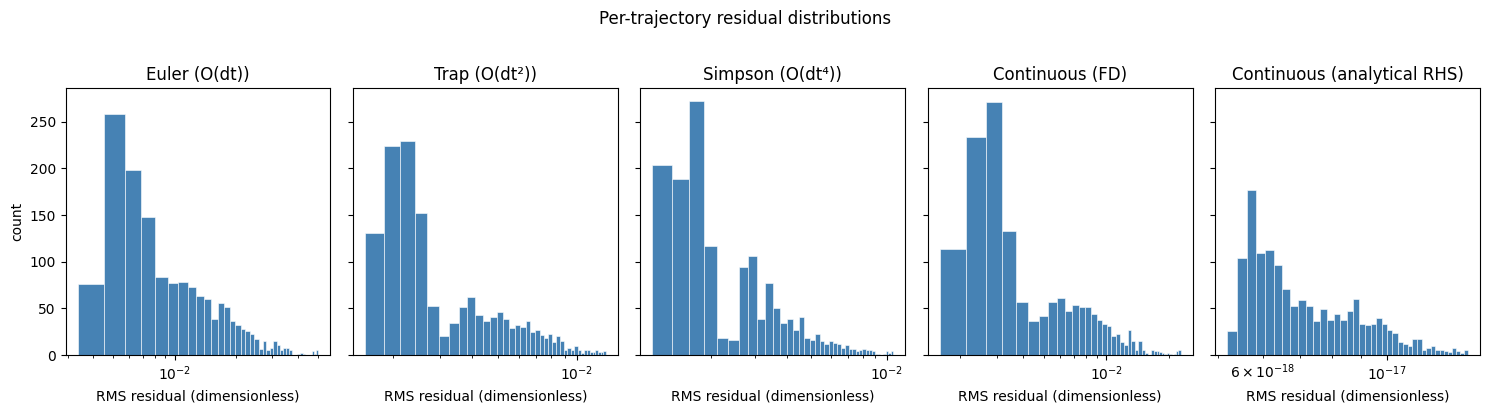

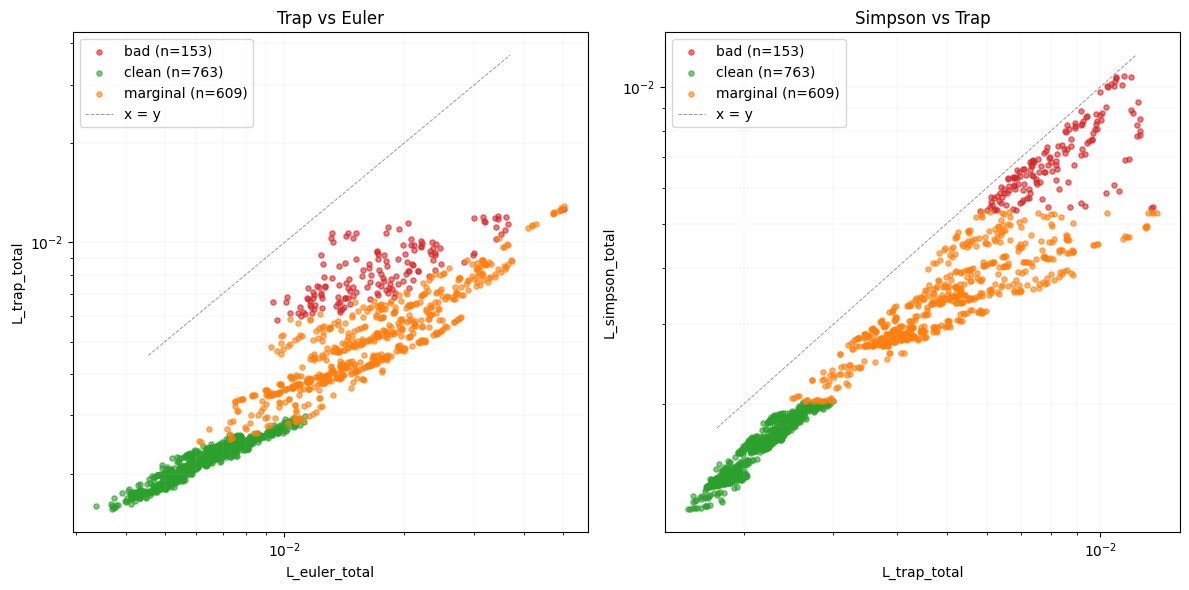

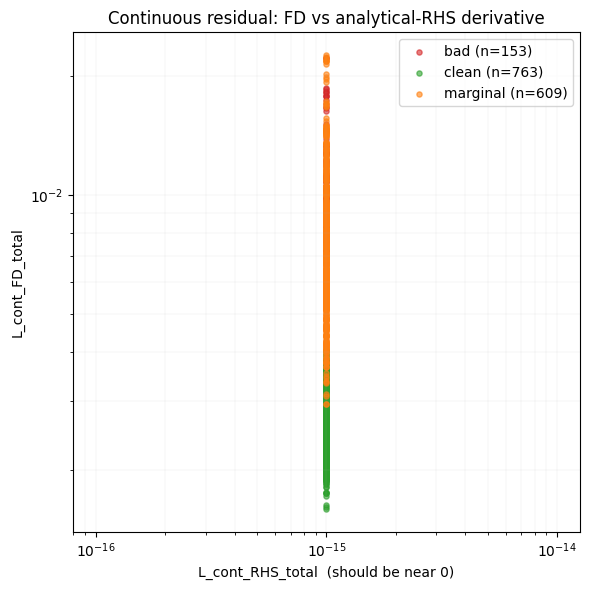

In [ ]:
plot_distributions(df, config)
plot_discretization_scatter(df, config)
plot_fd_vs_rhs_scatter(df, config)


## $\Delta t$-scaling Richardson check

This is the key plot for justifying any discretization upgrade in the
trainer. Subsample one trajectory by integer factors $k \in \{1, 2, 4, 8\}$
and recompute every metric. On a healthy trajectory the predictions are:

| Metric | Slope on log-log dt vs error |
|---|---|
| `L_euler`    | 1 |
| `L_trap`     | 2 |
| `L_simpson`  | 4 |
| `L_cont_FD`  | mostly flat at small $k$, climbs sharply once FD breaks down |
| `L_cont_RHS` | flat at machine precision |

**If Simpson stops dropping at slope 4 around the working `sampling_dt`,
that's the floor — likely interpolation error in $F$ between saved points.**
At that point, *no endpoint-only quadrature can do better*, and the
trainer's discrete residual gains nothing from going past Simpson.

If Simpson is still happily on slope 4 at your working `sampling_dt`, then
swapping the trainer's Euler residual for Simpson would tighten the
truncation floor by roughly a factor of `(dt_saved/dt_sampling)^3` — which
is the scaling of Simpson's gain over Euler.

In [18]:
def richardson_subsample(traj: Dict[str, Any], rp: RobotParams,
                         config: Dict[str, Any],
                         k_list=(1, 2, 4, 8)) -> pd.DataFrame:
    """Recompute residual metrics at several subsample factors."""
    rows = []
    for k in k_list:
        sub = {kn: (v[::k] if isinstance(v, np.ndarray) else v) for kn, v in traj.items()}
        d = diagnose_trajectory(sub, rp, config)
        rows.append({"k": k, "dt_eff": d.get("dt", np.nan),
                     "L_euler":     d.get("L_euler_total",   np.nan),
                     "L_trap":      d.get("L_trap_total",    np.nan),
                     "L_simpson":   d.get("L_simpson_total", np.nan),
                     "L_cont_FD":   d.get("L_cont_FD_total", np.nan),
                     "L_cont_RHS":  d.get("L_cont_RHS_total", np.nan)})
    return pd.DataFrame(rows)


def plot_richardson(traj: Dict[str, Any], rp: RobotParams, config: Dict[str, Any],
                    k_list=(1, 2, 4, 8)):
    rs = richardson_subsample(traj, rp, config, k_list=k_list)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    series = [("L_euler",   "o", "C0"),
              ("L_trap",    "s", "C1"),
              ("L_simpson", "D", "C2"),
              ("L_cont_FD", "^", "C3"),
              ("L_cont_RHS","x", "k")]
    for col, marker, color in series:
        ax.plot(rs["dt_eff"], rs[col].clip(lower=1e-18),
                marker=marker, color=color, label=col)

    # Reference slopes — anchored at the leftmost (smallest dt) point of L_euler
    if rs["dt_eff"].nunique() >= 2 and rs["L_euler"].iloc[0] > 0:
        x = rs["dt_eff"].to_numpy()
        x0 = x.min()
        y0 = rs["L_euler"].iloc[rs["dt_eff"].idxmin()] if False else rs["L_euler"].min()
        # Anchor each slope reference to the smallest-dt sample of L_euler
        idx_min = int(np.argmin(x))
        x_ref   = x
        y_anchor = float(rs["L_euler"].iloc[idx_min])
        for slope, style in [(1, "k--"), (2, "k:"), (4, "k-.")]:
            ax.plot(x_ref, y_anchor * (x_ref / x[idx_min]) ** slope,
                    style, lw=0.6, alpha=0.4, label=f"slope {slope} ref")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("effective dt (s)")
    ax.set_ylabel("RMS residual")
    ax.set_title(f"Richardson check  —  {traj['id'][:60]}…")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, which="both", lw=0.3, alpha=0.3)
    fig.tight_layout()
    plt.show()
    return rs

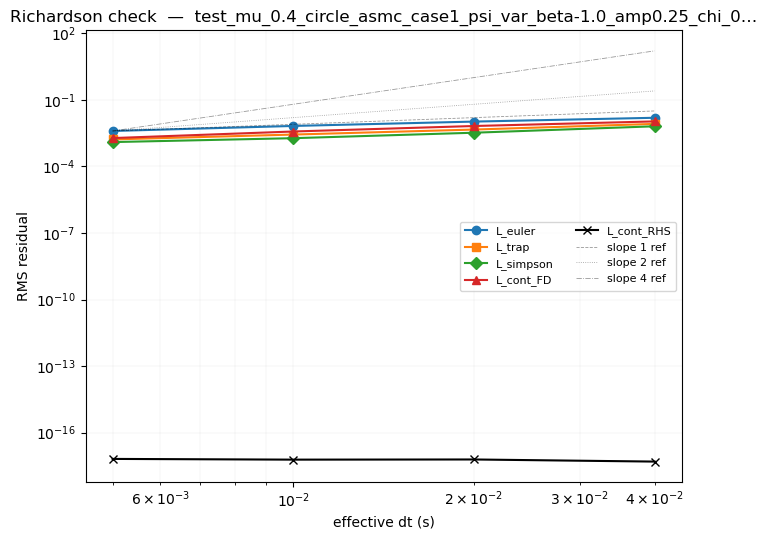

,k,dt_eff,L_euler,L_trap,L_simpson,L_cont_FD,L_cont_RHS
0,1,0.005,0.003976,0.001655,0.001255,0.001902,6.480978e-18
1,2,0.010,0.006704,0.002743,0.001882,0.003766,6.015449e-18
2,4,0.020,0.010537,0.004611,0.003319,0.006663,6.120339e-18
3,8,0.040,0.015664,0.008302,0.006471,0.010742,4.912954e-18


In [22]:
#clean_id = df.loc[df["tier"] == "clean", "id"].iloc[0]
#clean_traj = next(t for t in trajectories if t["id"] == clean_id)
plot_richardson(trajectories[0], rp, config, k_list=(1, 2, 4, 8))

richardson:   0%|          | 0/1525 [00:00<?, ?traj/s]

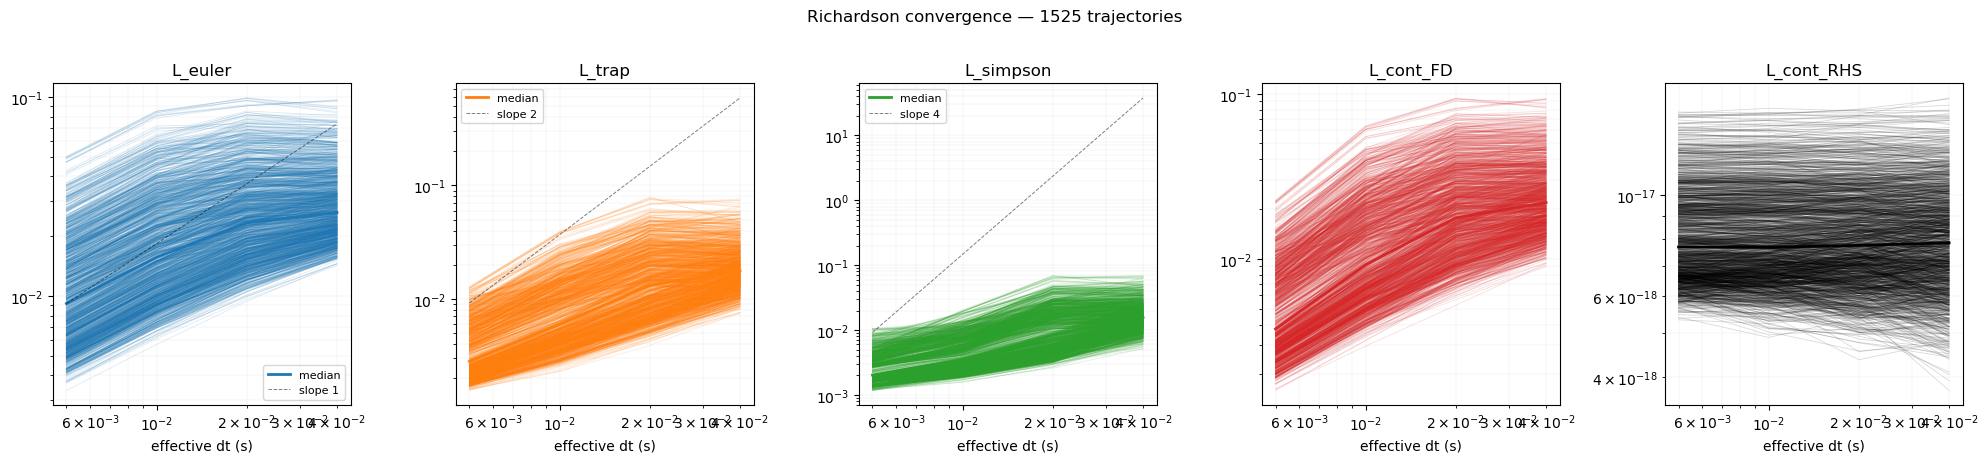

In [23]:
def plot_richardson_all(trajectories, rp, config, k_list=(1, 2, 4, 8),
                        max_trajs=None, alpha=0.15):
    """Overlay Richardson curves for every trajectory on one figure.

    Each metric gets its own subplot. Each trajectory contributes one
    semi-transparent line per subplot; the median across trajectories is
    drawn opaque on top.
    """
    if max_trajs is not None:
        trajectories = trajectories[:max_trajs]

    metrics = ["L_euler", "L_trap", "L_simpson", "L_cont_FD", "L_cont_RHS"]
    colors  = {"L_euler": "C0", "L_trap": "C1", "L_simpson": "C2",
               "L_cont_FD": "C3", "L_cont_RHS": "k"}

    # Collect (n_trajs, n_k) arrays for each metric
    n_k = len(k_list)
    data = {m: np.full((len(trajectories), n_k), np.nan) for m in metrics}
    dt_eff = np.full(n_k, np.nan)

    for i, traj in enumerate(tqdm(trajectories, desc="richardson", unit="traj")):
        rs = richardson_subsample(traj, rp, config, k_list=k_list)
        if i == 0:
            dt_eff = rs["dt_eff"].to_numpy()
        for m in metrics:
            data[m][i] = rs[m].to_numpy()

    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4.5),
                             sharex=True)
    for ax, m in zip(axes, metrics):
        # Per-trajectory faint lines
        for row in data[m]:
            ax.plot(dt_eff, np.clip(row, 1e-18, None),
                    color=colors[m], alpha=alpha, lw=0.6)
        # Median across trajectories, opaque
        med = np.nanmedian(data[m], axis=0)
        ax.plot(dt_eff, np.clip(med, 1e-18, None),
                color=colors[m], lw=2.0, label="median")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("effective dt (s)")
        ax.set_title(m)
        ax.grid(True, which="both", lw=0.3, alpha=0.3)

    # Reference slopes anchored at the median of L_euler at smallest dt
    if not np.all(np.isnan(data["L_euler"])):
        idx_min = int(np.nanargmin(dt_eff))
        y_anchor = float(np.nanmedian(data["L_euler"][:, idx_min]))
        for ax, m, slope in [(axes[0], "L_euler", 1),
                             (axes[1], "L_trap", 2),
                             (axes[2], "L_simpson", 4)]:
            ax.plot(dt_eff, y_anchor * (dt_eff / dt_eff[idx_min]) ** slope,
                    "k--", lw=0.7, alpha=0.5, label=f"slope {slope}")
            ax.legend(fontsize=8)

    fig.suptitle(f"Richardson convergence — {len(trajectories)} trajectories",
                 y=1.02)
    fig.tight_layout()
    plt.show()
    return data, dt_eff


# Usage:
data, dt_eff = plot_richardson_all(trajectories, rp, config, k_list=(1, 2, 4, 8))

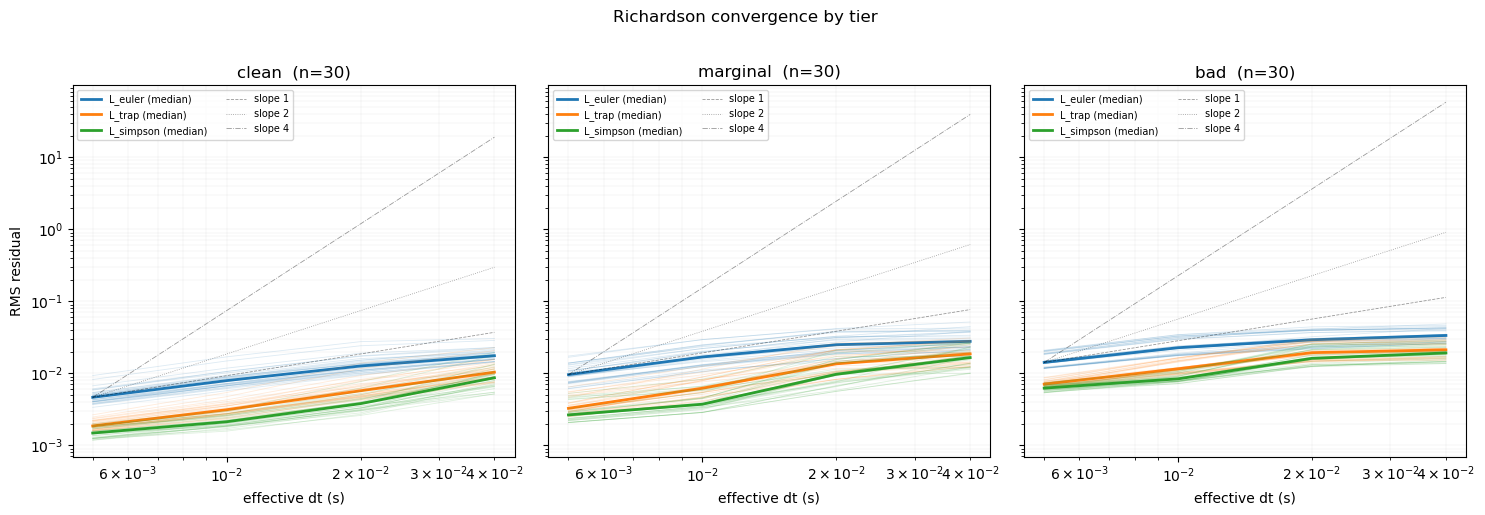

In [26]:
def plot_richardson_by_tier(df, trajectories, rp, config,
                            k_list=(1, 2, 4, 8),
                            max_per_tier=30,
                            metrics=("L_euler", "L_trap", "L_simpson")):
    """Per-tier Richardson overlay. Three subplots, one per tier;
    each metric drawn as a faded bundle plus its median.

    Reveals where Simpson's O(dt^4) advantage actually materializes
    (clean) vs where it collapses to Trap (bad).
    """
    id_to_traj = {t["id"]: t for t in trajectories}
    tiers = ["clean", "marginal", "bad"]
    colors = {"L_euler": "C0", "L_trap": "C1", "L_simpson": "C2",
              "L_cont_FD": "C3", "L_cont_RHS": "k"}

    fig, axes = plt.subplots(1, len(tiers), figsize=(5 * len(tiers), 5),
                             sharey=True)

    for ax, tier_name in zip(axes, tiers):
        ids = df.loc[df["tier"] == tier_name, "id"].head(max_per_tier).tolist()
        if not ids:
            ax.set_title(f"{tier_name} (empty)")
            continue

        # Collect (n_traj, n_k) arrays per metric
        n_k = len(k_list)
        bundles = {m: np.full((len(ids), n_k), np.nan) for m in metrics}
        dt_eff = None
        for i, tid in enumerate(ids):
            rs = richardson_subsample(id_to_traj[tid], rp, config, k_list=k_list)
            if dt_eff is None:
                dt_eff = rs["dt_eff"].to_numpy()
            for m in metrics:
                bundles[m][i] = rs[m].to_numpy()

        # Faded per-trajectory lines + opaque median per metric
        for m in metrics:
            for row in bundles[m]:
                ax.plot(dt_eff, np.clip(row, 1e-18, None),
                        color=colors[m], alpha=0.15, lw=0.6)
            med = np.nanmedian(bundles[m], axis=0)
            ax.plot(dt_eff, np.clip(med, 1e-18, None),
                    color=colors[m], lw=2.0, label=f"{m} (median)")

        # Slope reference anchored at smallest dt
        if "L_euler" in metrics and not np.all(np.isnan(bundles["L_euler"])):
            idx_min = int(np.nanargmin(dt_eff))
            y_anchor = float(np.nanmedian(bundles["L_euler"][:, idx_min]))
            for slope, style in [(1, "k--"), (2, "k:"), (4, "k-.")]:
                ax.plot(dt_eff,
                        y_anchor * (dt_eff / dt_eff[idx_min]) ** slope,
                        style, lw=0.6, alpha=0.4, label=f"slope {slope}")

        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_title(f"{tier_name}  (n={len(ids)})")
        ax.set_xlabel("effective dt (s)")
        ax.grid(True, which="both", lw=0.3, alpha=0.3)
        ax.legend(fontsize=7, ncol=2)

    axes[0].set_ylabel("RMS residual")
    fig.suptitle("Richardson convergence by tier", y=1.02)
    fig.tight_layout()
    plt.show()


# Usage:
plot_richardson_by_tier(df, trajectories, rp, config,
                        k_list=(1, 2, 4, 8),
                        max_per_tier=30)

## Inspecting the bad tier

In [30]:
def plot_trajectory_residuals(traj: Dict[str, Any], rp: RobotParams,
                              config: Dict[str, Any]):
    s = traj["states"]; F = traj["forces"]; U = traj["controls"]; t = traj["times"]
    fmax = config["force_max"]; umax = config["control_max"]; wmax = config["w_max"]
    edge = config["fd_edge_drop"]

    R_simp  = discrete_residual_simpson(s, F, U, t, rp, fmax, umax, wmax)
    s_dot_fd = fd_central(s, t)
    R_cFD   = continuous_residual(s, F, U, s_dot_fd, rp, fmax, umax, wmax)

    t_pair  =t[1:-1] # 0.5 * (t[:-1] + t[1:])
    fig, axes = plt.subplots(3, 1, figsize=config["figsize_traj"], sharex=True)
    axes[0].plot(t_pair, np.linalg.norm(R_simp["platform"], axis=1), label="simpson (3-D)")
    axes[0].plot(t[edge:len(t)-edge],
                 np.linalg.norm(R_cFD["platform"][edge:len(t)-edge], axis=1),
                 label="cont-FD", alpha=0.7)
    axes[0].set_ylabel("|R_platform|"); axes[0].legend(loc="upper right")

    axes[1].plot(t_pair, np.linalg.norm(R_simp["wheel"], axis=1), label="simpson")
    axes[1].plot(t[edge:len(t)-edge],
                 np.linalg.norm(R_cFD["wheel"][edge:len(t)-edge], axis=1),
                 label="cont-FD", alpha=0.7)
    axes[1].set_ylabel("|R_wheel|"); axes[1].legend(loc="upper right")

    axes[2].plot(t_pair, np.linalg.norm(R_simp["theta"], axis=1), label="simpson")
    axes[2].plot(t[edge:len(t)-edge],
                 np.linalg.norm(R_cFD["theta"][edge:len(t)-edge], axis=1),
                 label="cont-FD", alpha=0.7)
    axes[2].set_ylabel("|R_theta|"); axes[2].set_xlabel("t (s)")
    axes[2].legend(loc="upper right")

    fig.suptitle(f"{traj['id'][:80]}", fontsize=10)
    fig.tight_layout()
    plt.show()


def inspect_worst(df: pd.DataFrame, trajectories: List[Dict[str, Any]],
                  rp: RobotParams, config: Dict[str, Any], n: int = None):
    if n is None:
        n = config["max_traj_plots"]
    primary = "L_simpson_total" if "L_simpson_total" in df.columns else "L_trap_total"
    bad = df[df["tier"] == "bad"].sort_values(primary, ascending=False).head(n)
    id_to_traj = {tr["id"]: tr for tr in trajectories}
    for _, row in bad.iterrows():
        traj = id_to_traj.get(row["id"])
        if traj is None: continue
        print(f"--- {row['id']}\n    {primary}={row[primary]:.3e}, "
              f"L_cont_FD_total={row['L_cont_FD_total']:.3e}, "
              f"fd_rhs_gap={row['fd_rhs_gap']:.3e}")
        plot_trajectory_residuals(traj, rp, config)

--- test_mu_0.4_straightline_asmc_case1_psi_var_beta330.0_amp0.75_chi_0.008__beta330.000_amp0.750_T10.00_chi0.008
    L_simpson_total=1.059e-02, L_cont_FD_total=1.227e-02, fd_rhs_gap=1.217e-02


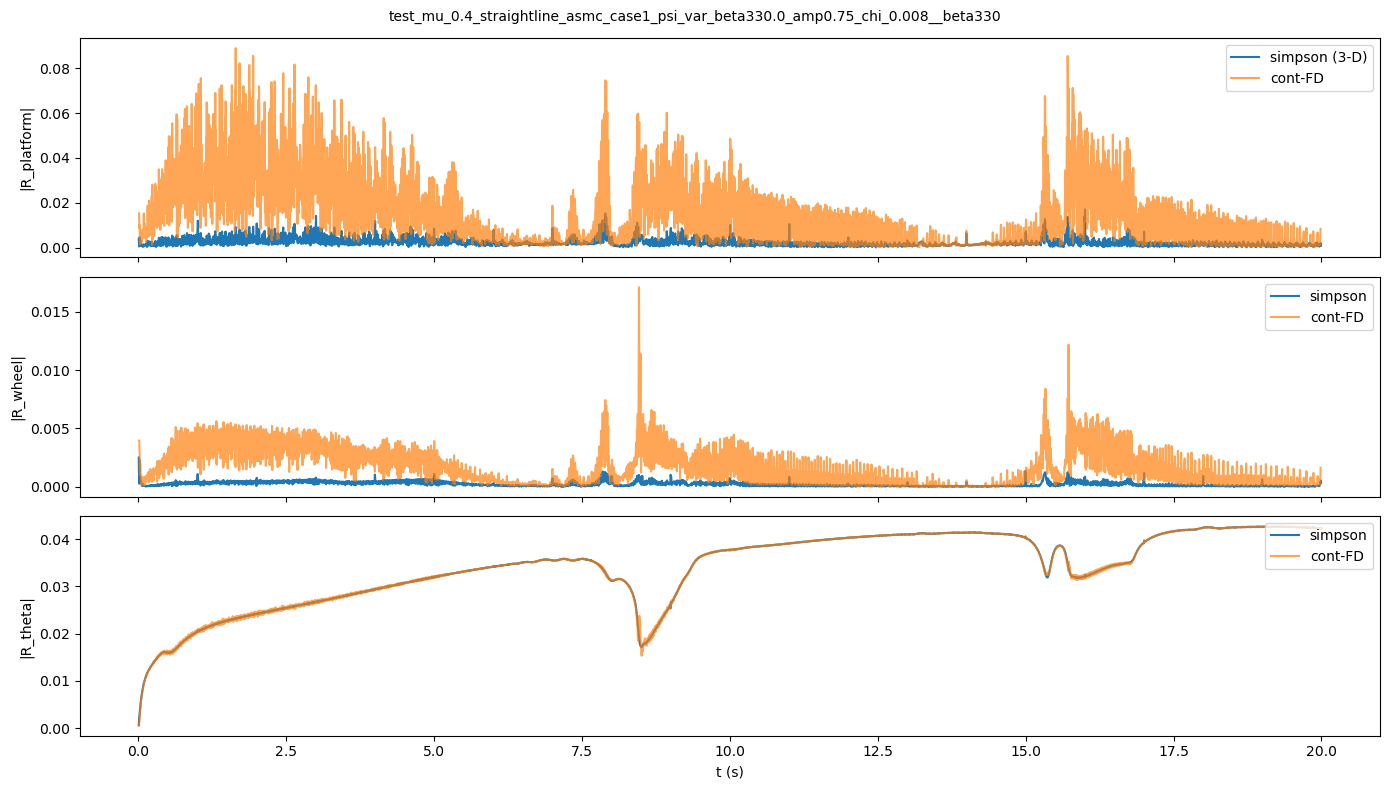

--- test_mu_0.4_straightline_asmc_case1_psi_var_beta345.0_amp0.75_chi_0.000__beta345.000_amp0.750_T10.00_chi0.000
    L_simpson_total=1.053e-02, L_cont_FD_total=1.109e-02, fd_rhs_gap=1.107e-02


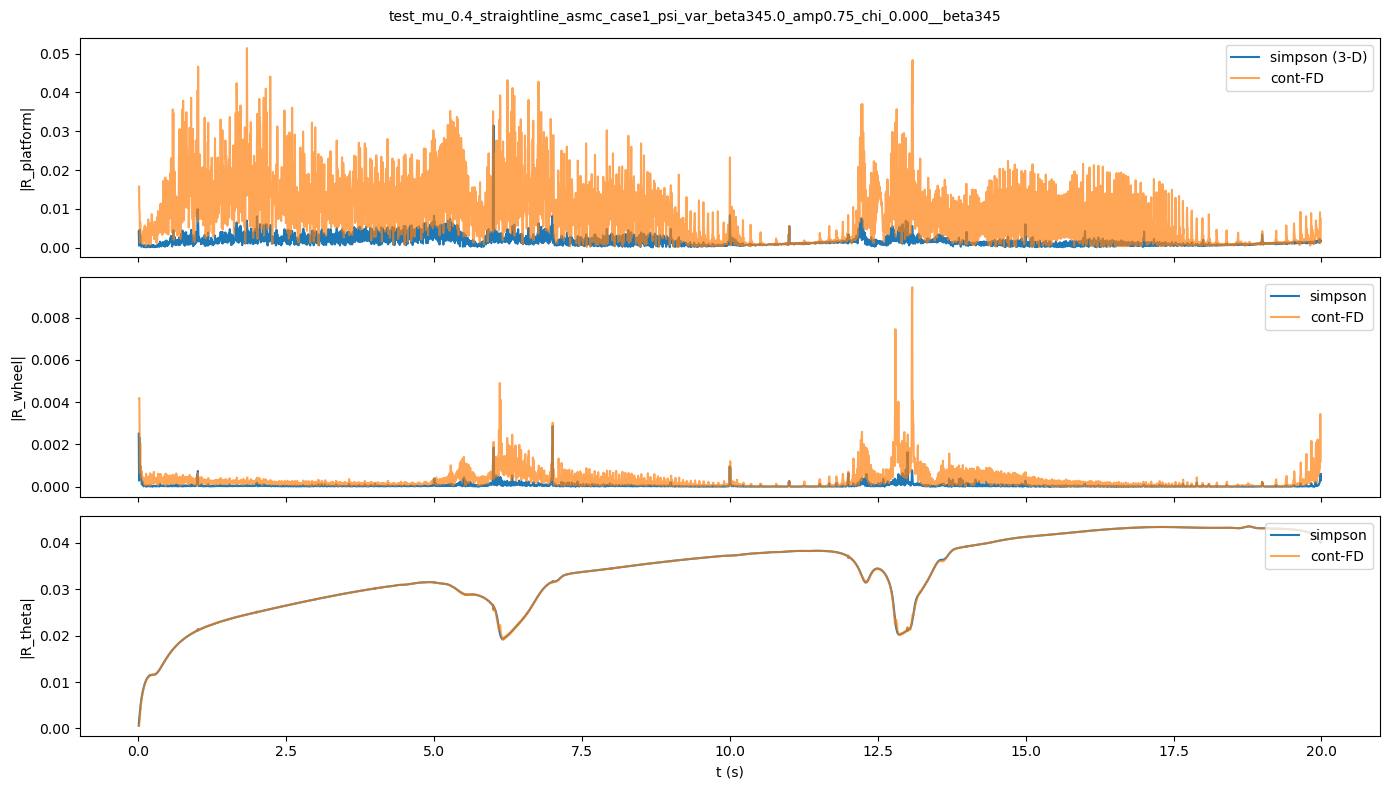

--- test_mu_0.4_straightline_asmc_case1_psi_var_beta315.0_amp0.75_chi_0.008__beta315.000_amp0.750_T10.00_chi0.008
    L_simpson_total=1.052e-02, L_cont_FD_total=1.351e-02, fd_rhs_gap=1.319e-02


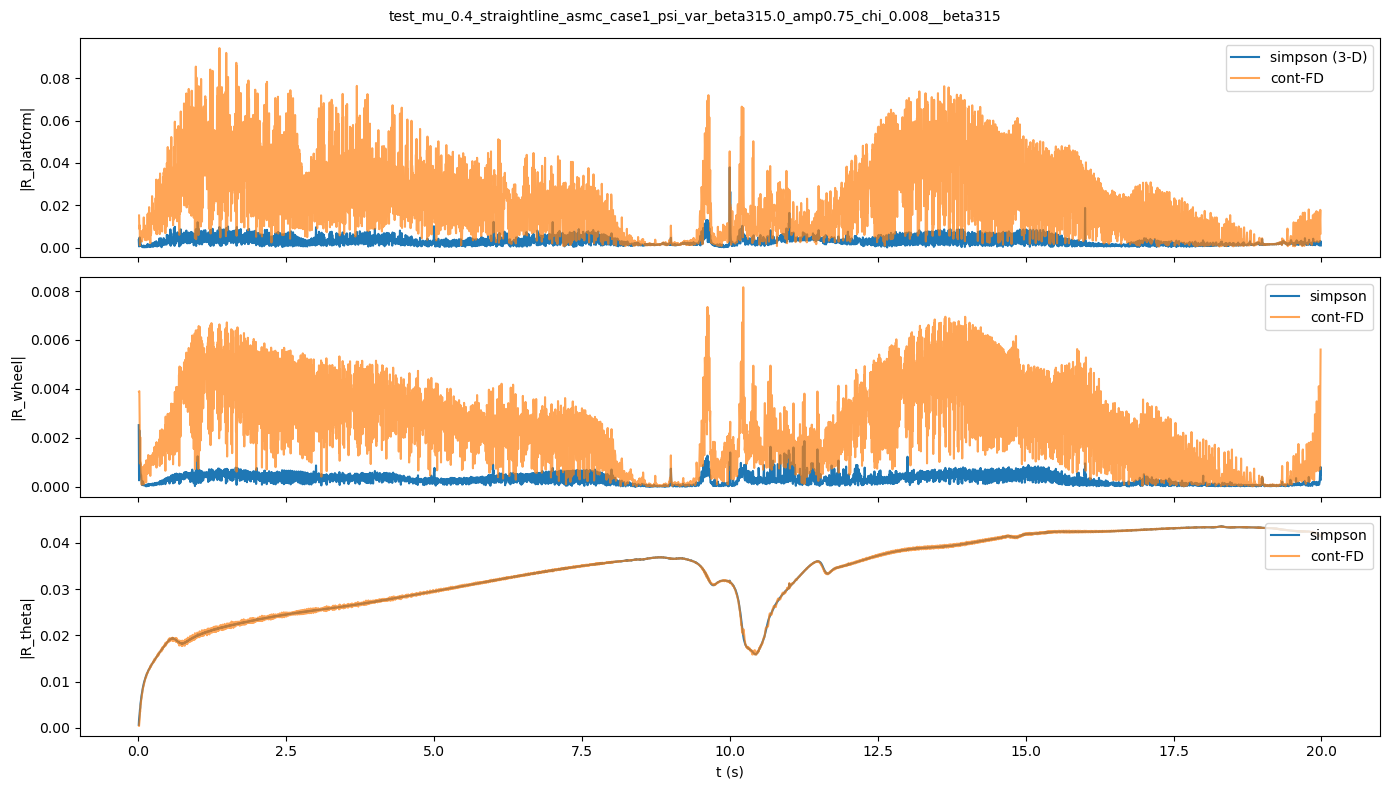

--- test_mu_0.4_straightline_asmc_case1_psi_var_beta345.0_amp0.75_chi_0.002__beta345.000_amp0.750_T10.00_chi0.002
    L_simpson_total=1.046e-02, L_cont_FD_total=1.123e-02, fd_rhs_gap=1.121e-02


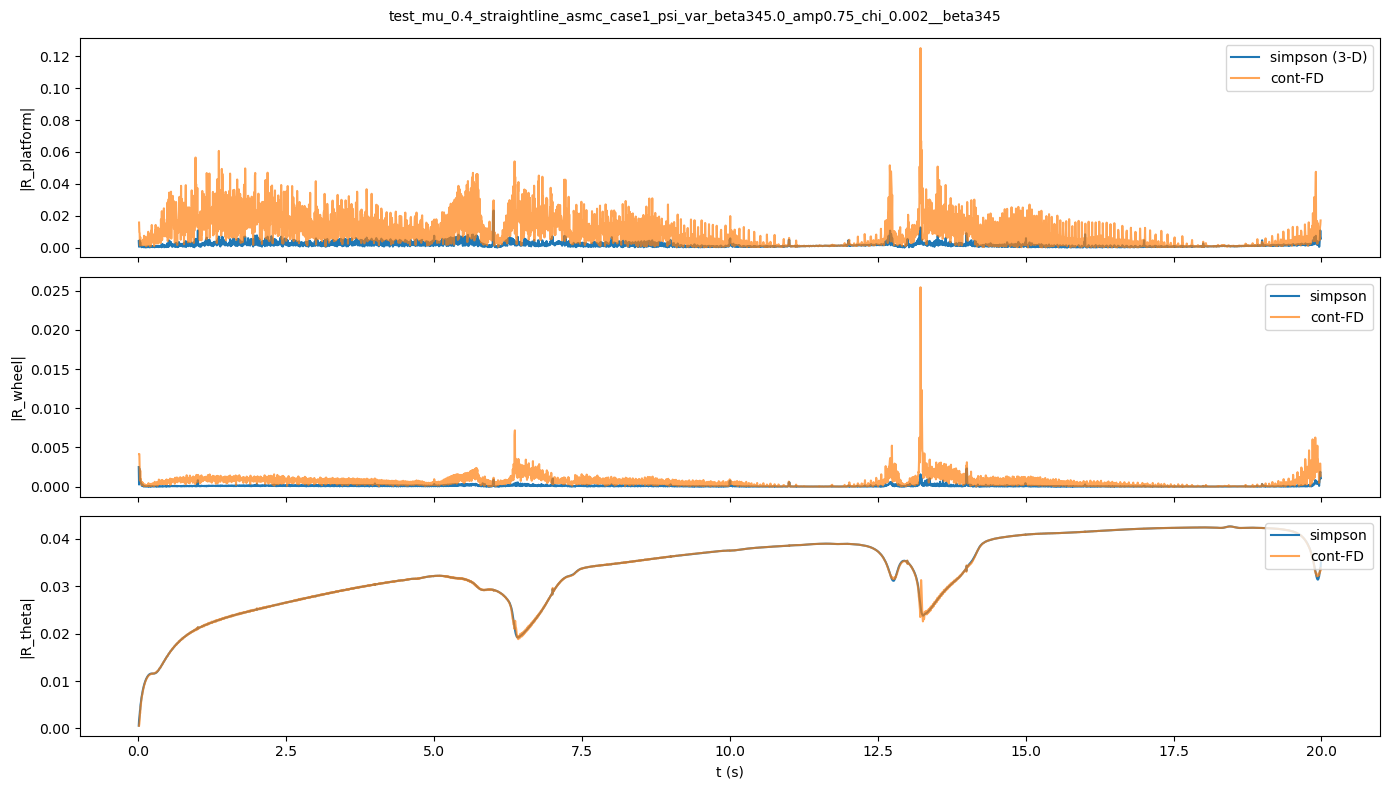

--- test_mu_0.4_straightline_asmc_case1_psi_var_beta315.0_amp0.75_chi_0.002__beta315.000_amp0.750_T10.00_chi0.002
    L_simpson_total=1.030e-02, L_cont_FD_total=1.148e-02, fd_rhs_gap=1.142e-02


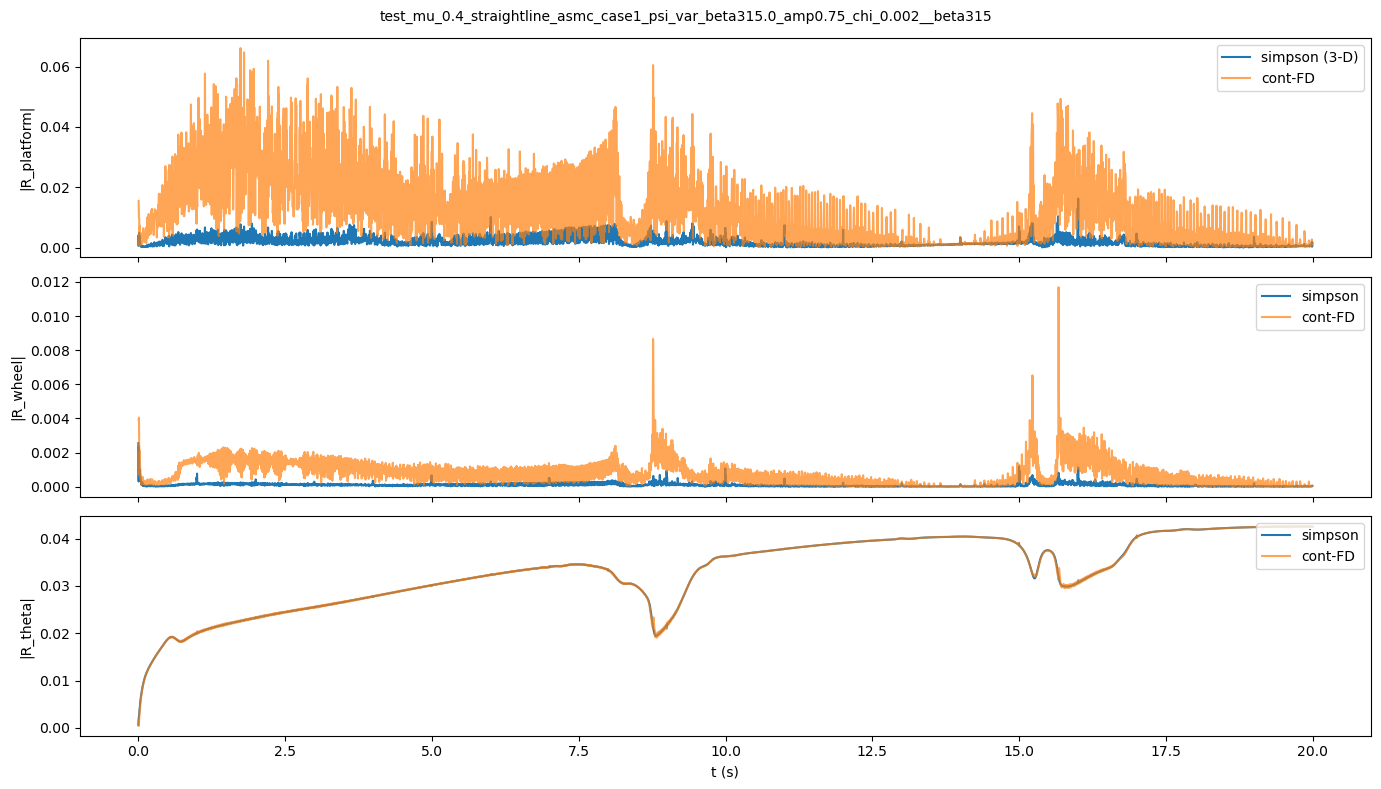

--- test_mu_0.4_straightline_asmc_case1_psi_var_beta0.0_amp0.75_chi_0.002__beta0.000_amp0.750_T10.00_chi0.002
    L_simpson_total=1.015e-02, L_cont_FD_total=1.119e-02, fd_rhs_gap=1.116e-02


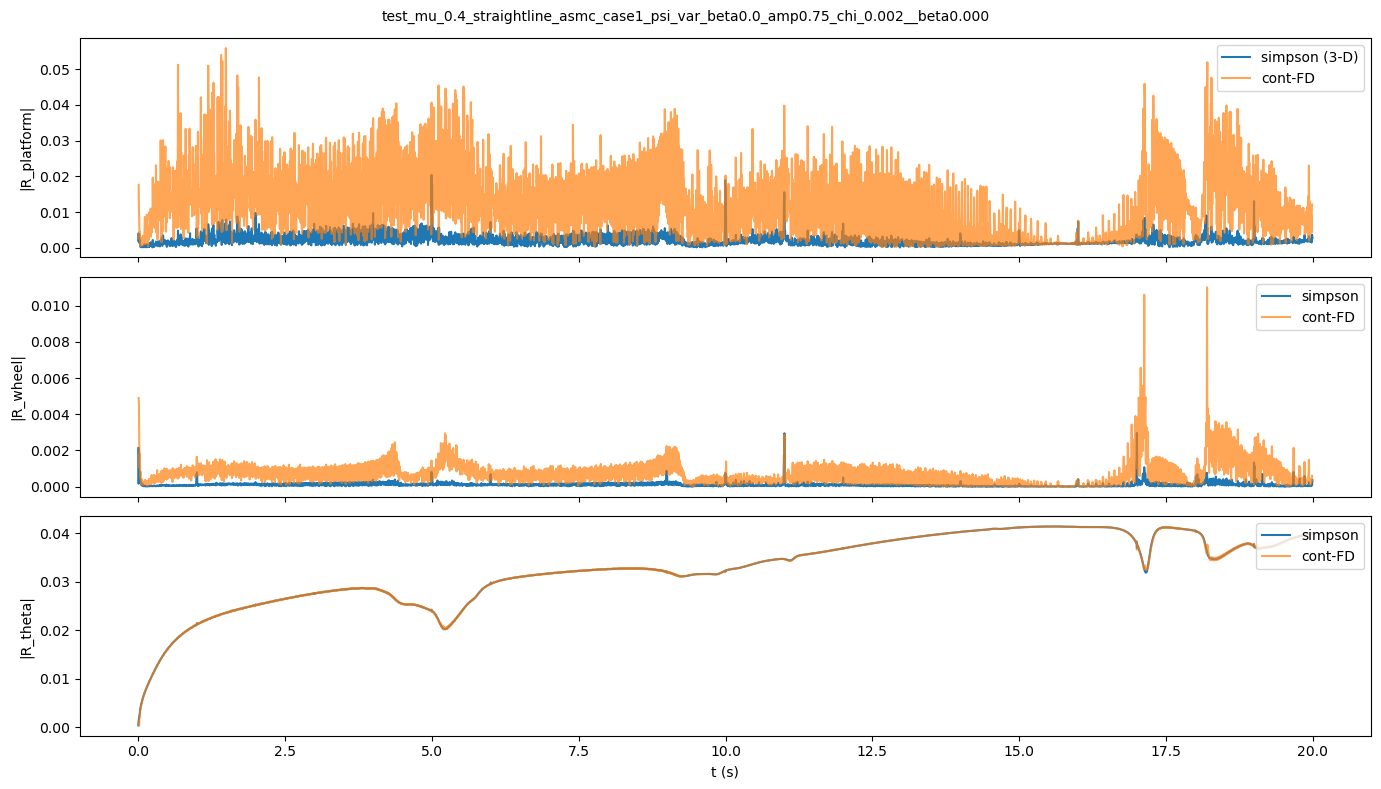

In [31]:
inspect_worst(df, trajectories, rp, config)

In [32]:
df.to_csv(r"C:\Users\vishv\OneDrive\Desktop\Vishvesh_Data\VNIT\Research Papers\IMECE 2026\trajectory physics diagnostics\trajectory_physics_diagnostic_s005.csv", index=False)

## End-to-end driver

```python
trajectories = load_diagnostic_trajectories(
    config["data_dir"],
    mu_values=config["mu_values"],
    motion_cases=config["motion_cases"],
    friction_case=config["friction_case"],
    subsample_factor=config["_subsample_factor"],
    max_window_sec=config["max_window_sec"],
)

df = diagnose_dataset(trajectories, rp, config)
df = classify_trajectories(df, config)

plot_distributions(df, config)
plot_discretization_scatter(df, config)
plot_fd_vs_rhs_scatter(df, config)

# Richardson convergence on a representative clean trajectory.
# This is THE plot to look at before deciding whether to swap the
# trainer's Euler residual for Simpson.
clean_traj = trajectories[df.loc[df["tier"]=="clean", "id"].iloc[0] == [t["id"] for t in trajectories]][0]
# (or just `trajectories[0]` if you don't want the clean filter)
plot_richardson(trajectories[0], rp, config, k_list=(1, 2, 4, 8))

inspect_worst(df, trajectories, rp, config)

df.to_csv("trajectory_diagnostic_v2.csv", index=False)
```

### Decision rule for promoting Simpson to the trainer

Run `plot_richardson` on 3–5 representative clean trajectories at your
target `sampling_dt = 0.005`. Then:

- **Simpson tracks slope 4 cleanly** → swap the trainer's discrete Euler
  for Simpson. Expect roughly $(\Delta t)^3$ tighter physics-residual floor.
- **Simpson flattens out at small dt while Euler/Trap still drop** → the
  floor is interpolation-error-limited. Don't bother changing the trainer's
  scheme; instead, regenerate data with finer `saveat`, or accept the
  current floor.
- **All three flatten together** → the trajectory has a non-discretization
  problem (parameter mismatch, stiff region, ASMC saturation). Investigate
  before training.